## 📊 01. Exploratory Data Analysis (EDA)

이 노트북은 학습에 사용될 메인 데이터셋의 질환, 환자, 메타데이터 분포를 파악하는 목적으로 사용됩니다.

### 🎯 주요 분석 내용
- **Class Distribution 분석**: 14개 주요 흉부 질환의 발생 빈도, 클래스 불균형 정도 파악
- **Co-occurrence 분석**: 두 가지 이상의 질환이 동시에 나타나는 빈도 분석
- **Metadata 분석**: 성별, 연령대 분포 등 서브그룹 분석 전에 데이터 통계 점검


In [3]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.preprocess.split import patient_wise_split

# 1. 원본 정답지(CSV) 먼저 불러오기
csv_path = '../data/Data_Entry_2017.csv'
df = pd.read_csv(csv_path)
print(f"원본 데이터 로딩 완료: 총 {len(df)}장")

# 2. 85:15로 분리
print("⏳ 환자 기준 데이터 분할을 시작합니다...")
train_df, _, test_df = patient_wise_split(
    df, 
    patient_col="Patient ID",
    val_ratio=0.0,            
    test_ratio=0.15,          
    seed=42                   
)

# 3. 결과 분석 (환자 수 vs 실제 이미지 장수 비율 확인)
total_imgs = len(train_df) + len(test_df)
train_img_ratio = (len(train_df) / total_imgs) * 100
test_img_ratio = (len(test_df) / total_imgs) * 100

print(f"\n--- 최종 이미지 장수 비율 검증 ---")
print(f"Train 이미지: {train_img_ratio:.2f}% ({len(train_df)}장)")
print(f"Test 이미지 : {test_img_ratio:.2f}% ({len(test_df)}장)")

원본 데이터 로딩 완료: 총 112120장
⏳ 환자 기준 데이터 분할을 시작합니다...
Split (patient-wise) — train: 95992 imgs (26185 pts), val: 0 imgs (0 pts), test: 16128 imgs (4620 pts)

--- 최종 이미지 장수 비율 검증 ---
Train 이미지: 85.62% (95992장)
Test 이미지 : 14.38% (16128장)


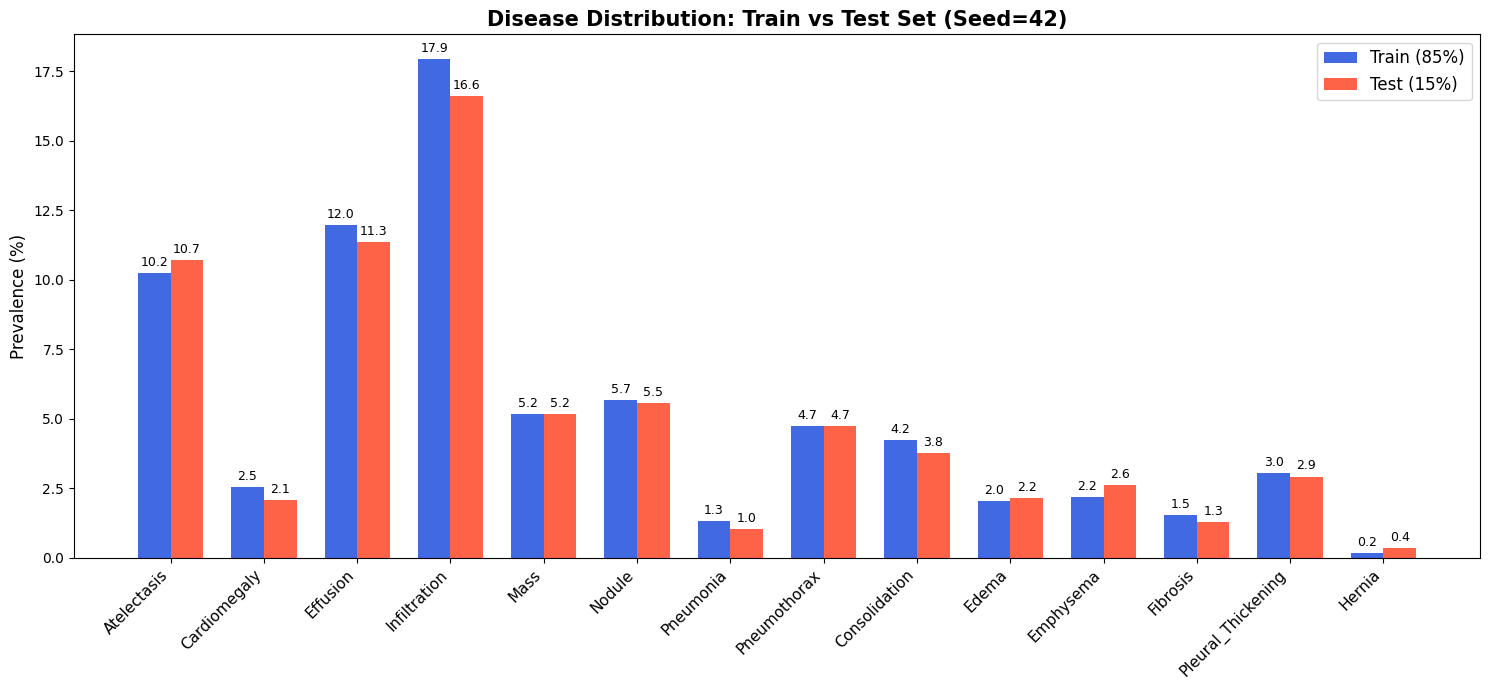


🚨 [희귀 질환 체크] 탈장(Hernia) 데이터 수
Train 세트: 170장 / Test 세트: 57장


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 14개 주요 흉부 질환 리스트
DISEASE_LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# 2. 각 세트에서 질환별 발생 비율(%)을 계산하는 함수
def get_disease_ratio(df, labels):
    ratios = []
    total_imgs = len(df)
    for disease in labels:
        # 해당 질환 문자가 포함된 이미지 개수를 세고 비율 계산
        count = df['Finding Labels'].str.contains(disease, regex=False).sum()
        ratios.append((count / total_imgs) * 100)
    return ratios

# Train / Test 비율 계산
train_ratios = get_disease_ratio(train_df, DISEASE_LABELS)
test_ratios = get_disease_ratio(test_df, DISEASE_LABELS)

# 3. 그래프 그리기
x = np.arange(len(DISEASE_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 7))
rects1 = ax.bar(x - width/2, train_ratios, width, label='Train (85%)', color='royalblue')
rects2 = ax.bar(x + width/2, test_ratios, width, label='Test (15%)', color='tomato')

ax.set_ylabel('Prevalence (%)', fontsize=12)
ax.set_title('Disease Distribution: Train vs Test Set (Seed=42)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DISEASE_LABELS, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)

ax.bar_label(rects1, fmt='%.1f', padding=3, size=9)
ax.bar_label(rects2, fmt='%.1f', padding=3, size=9)

plt.tight_layout()
plt.show()

# '탈장(Hernia)' 환자 수 팩트 체크
train_hernia = train_df['Finding Labels'].str.contains('Hernia', regex=False).sum()
test_hernia = test_df['Finding Labels'].str.contains('Hernia', regex=False).sum()
print(f"\n🚨 [희귀 질환 체크] 탈장(Hernia) 데이터 수")
print(f"Train 세트: {train_hernia}장 / Test 세트: {test_hernia}장")